# Dataset

Utilizamos el dataset MNIST que consta de numeros de 0 al 9 escritos a mano representados en imagenes de 28x28 px y su etiqueta. El dataset viene incluido en la libreria `tensorflow`.

Debido a que entrenar la red con PSO o algoritmos geneticos es un proceso lento, decidimos utilizar unicamente 1000 datapoints.


A continuacion se puede ver como lucen las imagenes

In [32]:
import collections
import tensorflow as tf
import numpy as np

data = tf.keras.datasets.mnist.load_data()
(x_train, y_train), (x_test, y_test) = data

sample_size = 2000
random_idx = np.random.randint(0, len(y_train), sample_size)

x_train, y_train = x_train[random_idx], y_train[random_idx]

data = (x_train, y_train), (x_test, y_test)
print("Ocurrences of each class in the trainning dataset: ")
print(collections.Counter(y_train))  
print()

print("Ocurrences of each class in the test dataset: ")
print(collections.Counter(y_test))  

Ocurrences of each class in the trainning dataset: 
Counter({1: 240, 2: 225, 9: 217, 8: 216, 0: 195, 3: 194, 6: 188, 7: 186, 5: 181, 4: 158})

Ocurrences of each class in the test dataset: 
Counter({1: 1135, 2: 1032, 7: 1028, 3: 1010, 9: 1009, 4: 982, 0: 980, 8: 974, 6: 958, 5: 892})


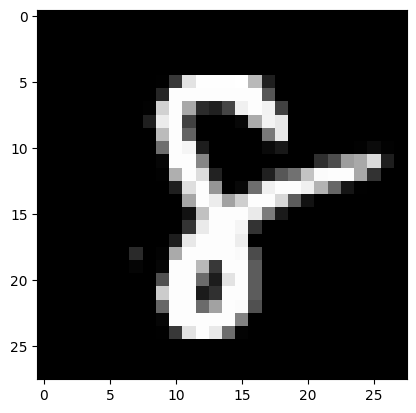

El numero en la imagen es:  8


In [33]:
from matplotlib import pyplot as plt

def show_digit(img):
    img = np.array(img, dtype='float')
    pixels = img.reshape((28, 28))
    plt.imshow(pixels, cmap='gray')
    plt.show()
show_digit(x_train[0])
print("El numero en la imagen es: ", y_train[0])

# Red neuronal

La red neuronal que utilizamos es una red neuronal fully-connected que consta de:
- Una capa de entrada de 784 elementos
- Una capa de intermedia con 128 neuronas y con activacion `relu`
- Una capa de intermedia con 64 neuronas y con activacion `relu`
- La capa de salia consta de 10 neuronas con activacion `softmax`

Para codificarla utilizamos la libreria `tensorflow`

```python
inputs = Input(shape=(784,))
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x) 
```

El comportamiento de la red neuronal se encuentra encapsulado en `model.NNModel`. Esta clase se 
inicializa con pesos aleatorios y tiene metodos adicionales para predecir, obtener metricas de rendimiento
y obtener y setear los pesos de la red.

In [34]:
from model import NNModel

demo_nn = NNModel()

demo_w = demo_nn.get_weights_as_numpy() # Obtiene todos los parametros de la red
demo_nn.set_custom_weights(demo_w) # Setea los parametros de la red

predicted = demo_nn.predict_digit(x_train[0])
print(f"El valor predecido para {y_train[0]} es: {predicted}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
El valor predecido para 8 es: 9


# PSO

Los parametros de la red neuronal representan una particula en PSO. Con la arquitectura de la red que estamos usando,
cada particula posee 109_386 posiciones.

Al ser un problema de clasificacion, decidimos usar el `F1 score` como funcion objetivo a maximizar. Para cada particula en PSO, se obtiene el `F1` con el dataset anteriormente mencionado. Luego, esta informacion se usa para actualizar las posiciones y velocidad de PSO.

Todo este comportamiento se encuentra en la clase `pso.PSO`

In [35]:
from pso import PSO
p = PSO(
    data=data,
    w=1.5,
    c_local=1,
    c_global=20,
    n_particles=20
)
fitness_pso = p.train(epochs=10)
p.print_report() # El reporte se genera con datos que no se encuetran en el dataset

Iter 0 best fitness: 0.07170602972689881. Global best 0.07170602972689881
Iter 1 best fitness: 0.105742859960488. Global best 0.105742859960488
Iter 2 best fitness: 0.11932693809284452. Global best 0.11932693809284452
Iter 3 best fitness: 0.12712942437836244. Global best 0.12712942437836244
Iter 4 best fitness: 0.12574812822170614. Global best 0.12712942437836244
Iter 5 best fitness: 0.1036102563700177. Global best 0.12712942437836244
Iter 6 best fitness: 0.12526548346096622. Global best 0.12712942437836244
Iter 7 best fitness: 0.10355782783327785. Global best 0.12712942437836244
Iter 8 best fitness: 0.12486986667694089. Global best 0.12712942437836244
Iter 9 best fitness: 0.12489047563284811. Global best 0.12712942437836244
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 442us/step
[(7, 4), (2, 3), (1, 3), (0, 0), (4, 7), (1, 3), (4, 3), (9, 3), (5, 0), (9, 3), (0, 4), (6, 4), (9, 4), (0, 0), (1, 4), (5, 3), (9, 3), (7, 4), (3, 3), (4, 0), (9, 0), (6, 3), (6, 0), (5, 4), (4, 3), (0, 0), (7, 3), (4, 3

/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
True: 4; predicted: 4


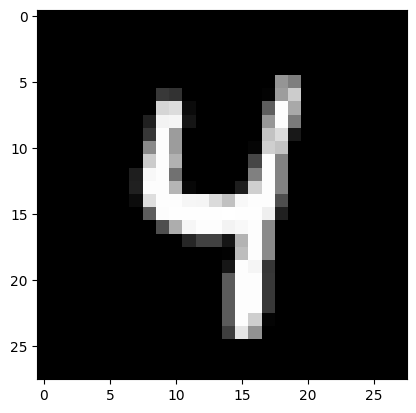

In [28]:
random_idx = np.random.randint(0, len(x_test))
x_to_predict = x_test[random_idx]
y_true = y_test[random_idx]
y_predicted = p._model.predict_digit(x_to_predict)

print(f"True: {y_true}; predicted: {y_predicted}")
show_digit(x_to_predict)

## Conclusion PSO



En relacion a los parametros de PSO, analizando con una matriz de dispersion en `analyze_params.ipynb` notamos que:
- Es mejor mantener un `w > 1` para asegurar convergencia
- Si `c_local > c_global` tiende a quedarse en un optimo local.

- Si la cantidad de particulas es mayor a 20 las iteraciones se vuelven muy lentas pero explora mas el espacio.
- Si la cantidad de particulas es menor a 10 las soluciones obtenidas no son buenas

- La solucion depende mucho de la aleatoridad. 
En la mayoria de los casos se queda en el optimo local donde
clasifica todos los datos con el mismo numero, asegurando una accuracy del 0.1.


# Algoritmo genetico

A modo de comparacion con PSO, tambien implementamos un algoritmo genetico con one point crossover.

<Axes: >

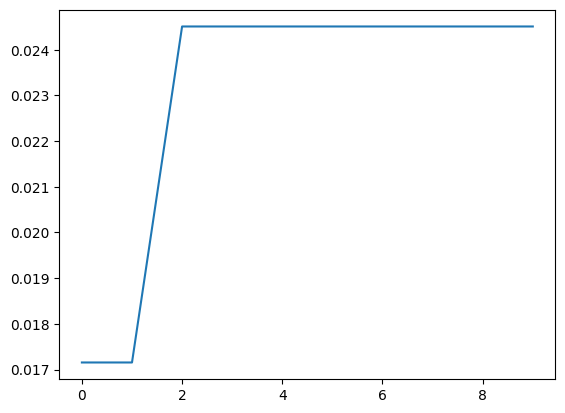

In [29]:
from ga import run_ga
import seaborn as sns

fitness_ga, pop= run_ga(generations=10, pop_size=10, sample_size=sample_size)
sns.lineplot(x=range(len(fitness_ga)), y=fitness_ga)

In [30]:
best_w_ga = pop.iloc[0].individuos
p._model.set_custom_weights(best_w_ga)
p._best_weights = best_w_ga
p.print_report()

  1/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
[(7, 7), (2, 7), (1, 7), (0, 7), (4, 7), (1, 7), (4, 7), (9, 7), (5, 7), (9, 7), (0, 7), (6, 7), (9, 7), (0, 7), (1, 7), (5, 7), (9, 7), (7, 7), (3, 7), (4, 7), (9, 7), (6, 7), (6, 7), (5, 7), (4, 7), (0, 7), (7, 7), (4, 7), (0, 7), (1, 7), (3, 7), (1, 7), (3, 7), (4, 7), (7, 7), (2, 7), (7, 7), (1, 7), (2, 7), (1, 7), (1, 7), (7, 7), (4, 7), (2, 7), (3, 7), (5, 7), (1, 7), (2, 7), (4, 7), (4, 7), (6, 7), (3, 7), (5, 7), (5, 7), (6, 7), (0, 7), (4, 7), (1, 7), (9, 7), (5, 7), (7, 7), (8, 7), (9, 7), (3, 7), (7, 7), (4, 7), (6, 7), (4, 7), (3, 7), (0, 7), (7, 7), (0, 7), (2, 7), (9, 7), (1, 7), (7, 7), (3, 7), (2, 7), (9, 7), (7, 7), (7, 7), (6, 7), (2, 7), (7, 7), (8, 7), (4, 7), (7, 7), (3, 7), (6, 7), (1, 7), (3, 7), (6, 7), (9, 7), (3, 7), (1, 7), (4, 7), (1, 7), (7, 7), (6, 7), (9, 7), (6, 7), (0, 7), (5, 7), (4, 7), (9, 7), (9, 7), (2, 7), (1, 7), (9, 7), (4, 7), (8, 7), (7, 7), (3, 7), (9, 7), (7, 7), (4, 7), (4, 7), (4, 7), (9, 7), (2, 

/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/vscode/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Conclusiones

Podemos observar que las heuristicas funcionan pero son muy sensibles a la incializacion y optimos locales. Para este caso en particular, PSO obtuvo mejores resultados.



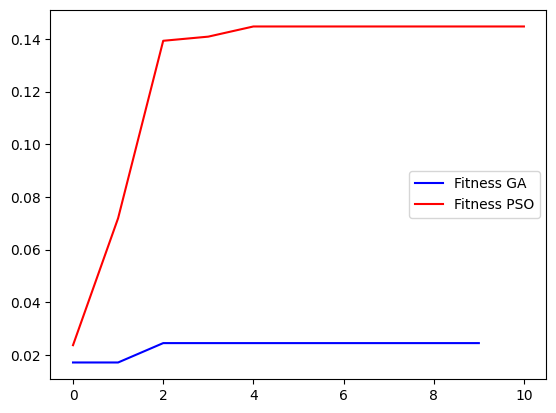

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=range(len(fitness_ga)), y=fitness_ga, color='blue', label='Fitness GA')
sns.lineplot(x=range(len(fitness_pso)), y=fitness_pso, color='red', label='Fitness PSO')
plt.legend()
plt.show()

# Backpropagation

In [32]:
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score
import numpy as np

class F1ScoreCallback(Callback):
    def __init__(self, validation_data):
        super(F1ScoreCallback, self).__init__()
        self.validation_data = validation_data
        self.f1_scores = []

    def on_epoch_end(self, epoch, logs=None):
        x_val, y_val = self.validation_data
        y_pred = np.argmax(self.model.predict(x_val), axis=1)
        f1 = f1_score(y_val, y_pred, average='weighted')
        self.f1_scores.append(f1)
        print(f'\nF1-Score for epoch {epoch+1} is {f1}')

In [29]:
f1_callback = F1ScoreCallback((x_test, y_test))

x_train = x_train / 255.0
x_test = x_test / 255.0
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Flatten the images from 28x28 to 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
p1 = PSO(data, 1,1,1)
p1._model.model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test,y_test), callbacks=[f1_callback])
# After training, f1_callback.f1_scores will contain the F1 scores for each epoch
best_f1_scores = f1_callback.f1_scores



Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/stepep - accuracy: 0.4352 - loss: 2365

F1-Score for epoch 1 is 0.7878470857113533
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 977us/step - accuracy: 0.4409 - loss: 230033.9844 - val_accuracy: 0.8030 - val_loss: 1832.2983
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/stepep - accuracy: 0.7415 - loss: 3927

F1-Score for epoch 2 is 0.7900162608712191
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 950us/step - accuracy: 0.7416 - loss: 3926.9099 - val_accuracy: 0.7890 - val_loss: 3196.8906
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 492us/stepep - accuracy: 0.7996 - loss: 36

F1-Score for epoch 3 is 0.777534591151978
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 958us/step - accuracy: 0.7997 - loss: 3626.3250 - val_accuracy: 0.8032 - val_loss: 4764.9600
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/stepep - accuracy: 0.8228 - loss: 34

F1-Score for epoch 4 is 0.8024427736068331
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 988us/step - accuracy: 0.8229 - loss: 3472.3679 - val_accura

[0.7878470857113533,
 0.7900162608712191,
 0.777534591151978,
 0.8024427736068331,
 0.8625885093698086,
 0.8304862115326718,
 0.9108231932512095,
 0.8684119205205061,
 0.8591012397560854,
 0.927477851189427]

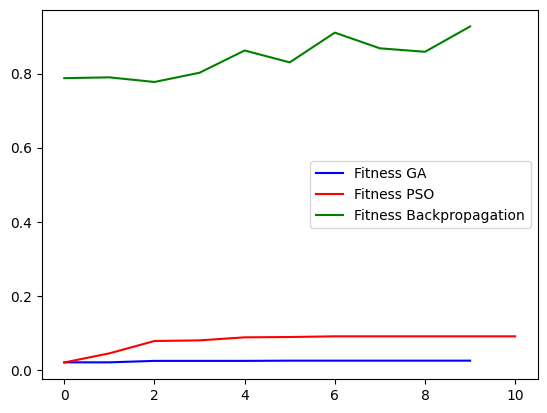

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=range(len(fitness_ga)), y=fitness_ga, color='blue', label='Fitness GA')
sns.lineplot(x=range(len(fitness_pso)), y=fitness_pso, color='red', label='Fitness PSO')
sns.lineplot(x=range(len(best_f1_scores)), y=best_f1_scores, color='green', label='Fitness Backpropagation')
plt.legend()
plt.show()